<a href="https://colab.research.google.com/github/jamesmignone63-create/UofUtah_IS4487/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IS4487 Assignment 10: Classfication with Decision Trees**

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/vandanara/UofUtah_IS4487/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

## **Task 1. Import libraries, Load the Data and Preview it**

1.1. Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib

1.2. Initial Data Understanding
- Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to Assignments > DataSets)

1.3. Preview the data
- Describe or profile the dataframe
- Look for any outliers, missing values, or duplicates (enough to describe it)

In [104]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt

In [105]:
df = pd.read_csv('/content/adviseinvest_historical_data.csv')

In [106]:
 # 🔧 1.3. Preview the data
df.head()
 # View a few rows
df.head(10)
 # View the datatypes
df.info()
 # Describe the data
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   answered        29504 non-null  int64  
 1   income          29504 non-null  int64  
 2   female          29504 non-null  object 
 3   age             29504 non-null  int64  
 4   job             29504 non-null  int64  
 5   num_dependents  29504 non-null  int64  
 6   rent            29504 non-null  int64  
 7   own_res         29504 non-null  int64  
 8   new_car         29502 non-null  float64
 9   chk_acct        29504 non-null  int64  
 10  sav_acct        29504 non-null  int64  
 11  num_accts       29504 non-null  int64  
 12  mobile          29504 non-null  int64  
 13  product         29504 non-null  int64  
dtypes: float64(1), int64(12), object(1)
memory usage: 3.2+ MB


,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


## **Task 2. Data Preparation**

### **2.1. Data Cleanup**
2.1.1. Delete any obvious outliers

2.1.2. Remove any variables that are not relevant to our analysis (be sure not to delete too many variables, you may need them in the near future!)

2.1.3 Clean up any missing data or non-standardized data.

Save the data in a new datafram named "df_clean"


In [107]:
Q1 = df_clean[['income', 'age', 'num_accts']].quantile(0.25)
Q3 = df_clean[['income', 'age', 'num_accts']].quantile(0.75)
IQR = Q3 - Q1

df_clean = df_clean[~((df_clean[['income', 'age', 'num_accts']] < (Q1 - 1.5 * IQR)) | (df_clean[['income', 'age', 'num_accts']] > (Q3 + 1.5 * IQR))).any(axis=1)].copy()

print("Shape of df_clean after removing outliers:", df_clean.shape)

Shape of df_clean after removing outliers: (23036, 13)


In [108]:
if 'product' in df_clean.columns:
    df_clean = df_clean.drop('product', axis=1)

In [109]:
df_clean.isnull().sum()
df_clean.fillna({'new_car': df_clean['new_car'].mode()[0]}, inplace=True)

In [110]:
df_clean.fillna({'new_car': df_clean['new_car'].mode()[0]}, inplace=True)
df_clean['new_car'] = df_clean['new_car'].astype(int)
print(df_clean.isnull().sum())
print(df_clean.info())


answered          0
income            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           0
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
housing           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 23036 entries, 1 to 29502
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        23036 non-null  category
 1   income          23036 non-null  int64   
 2   age             23036 non-null  int64   
 3   job             23036 non-null  category
 4   num_dependents  23036 non-null  category
 5   rent            23036 non-null  category
 6   own_res         23036 non-null  category
 7   new_car         23036 non-null  int64   
 8   chk_acct        23036 non-null  category
 9   sav_acct        23036 non-null  category
 10  num_accts       23036 non-null  int64   
 11  mobile          2303

### **2.2. Clean up the data types of features. Convert to int**

 2.2.1. Convert any variables that should be an integer into an integer

In [111]:
print("Data types:")
print(df_clean.info())

Data types:
<class 'pandas.core.frame.DataFrame'>
Index: 23036 entries, 1 to 29502
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        23036 non-null  category
 1   income          23036 non-null  int64   
 2   age             23036 non-null  int64   
 3   job             23036 non-null  category
 4   num_dependents  23036 non-null  category
 5   rent            23036 non-null  category
 6   own_res         23036 non-null  category
 7   new_car         23036 non-null  int64   
 8   chk_acct        23036 non-null  category
 9   sav_acct        23036 non-null  category
 10  num_accts       23036 non-null  int64   
 11  mobile          23036 non-null  category
 12  housing         23036 non-null  object  
dtypes: category(8), int64(4), object(1)
memory usage: 1.2+ MB
None


### **2.3. Clean up the data types of features. Convert to categorical**

2.3.1. Change the target, `answered` to yes/no and make it categorical

2.3.2. Find at least 8 variables that would be appropriate to convert to categories

In [112]:
# 🔧 2.3.1. Change the target, `answered` to yes/no and make it categorical
df_clean['answered'] = df_clean['answered'].astype('category')

In [113]:
# 🔧 2.3.2. Convert categorical variables
categorical_cols = ['job', 'num_dependents', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile']

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

# Verify the changes
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 23036 entries, 1 to 29502
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   answered        23036 non-null  category
 1   income          23036 non-null  int64   
 2   age             23036 non-null  int64   
 3   job             23036 non-null  category
 4   num_dependents  23036 non-null  category
 5   rent            23036 non-null  category
 6   own_res         23036 non-null  category
 7   new_car         23036 non-null  category
 8   chk_acct        23036 non-null  category
 9   sav_acct        23036 non-null  category
 10  num_accts       23036 non-null  int64   
 11  mobile          23036 non-null  category
 12  housing         23036 non-null  object  
dtypes: category(9), int64(3), object(1)
memory usage: 1.1+ MB
None


## **Task 3: Exploratory Data Analysis (EDA)**

### **3.1.-3.5. Draw charts**
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



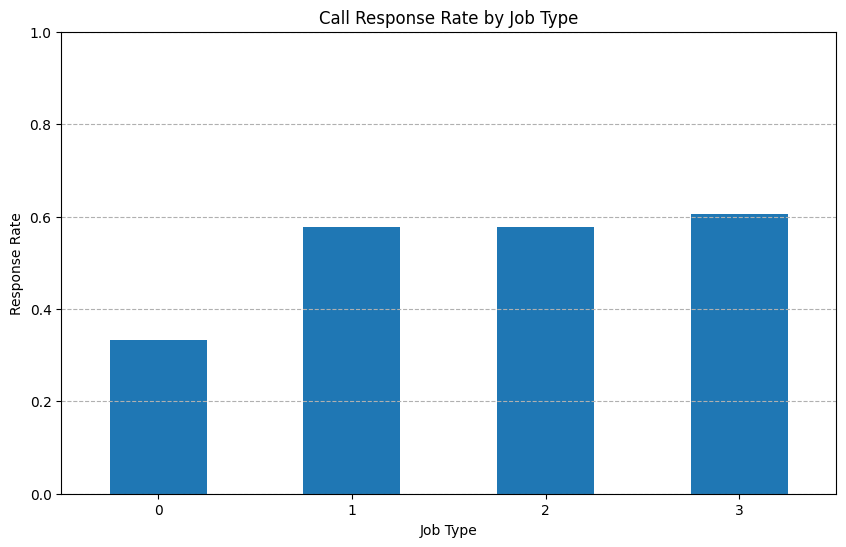

In [114]:
plt.figure(figsize=(10, 6))
response_rate_by_job.plot(kind='bar')
plt.title('Call Response Rate by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Response Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--')
plt.show()

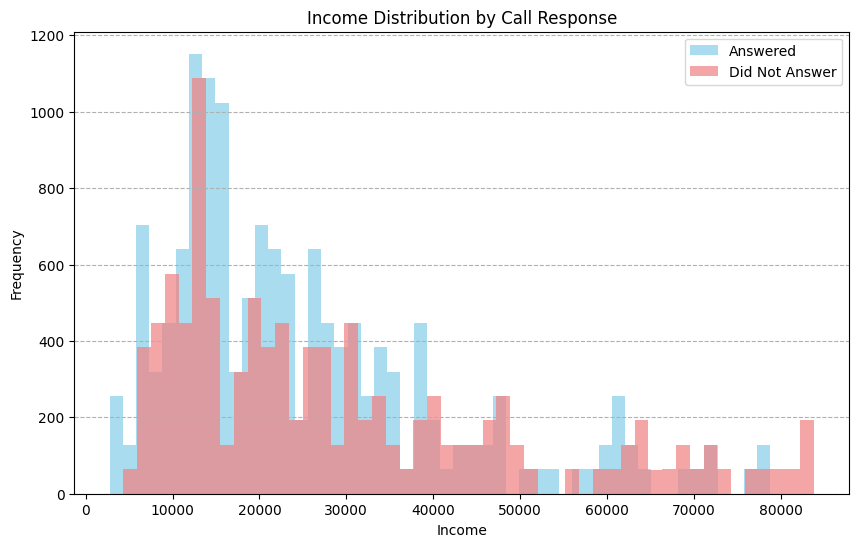

In [115]:
plt.figure(figsize=(10, 6))
plt.hist(answered_income, bins=50, alpha=0.7, label='Answered', color='skyblue')
plt.hist(not_answered_income, bins=50, alpha=0.7, label='Did Not Answer', color='lightcoral')

plt.title('Income Distribution by Call Response')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.show()

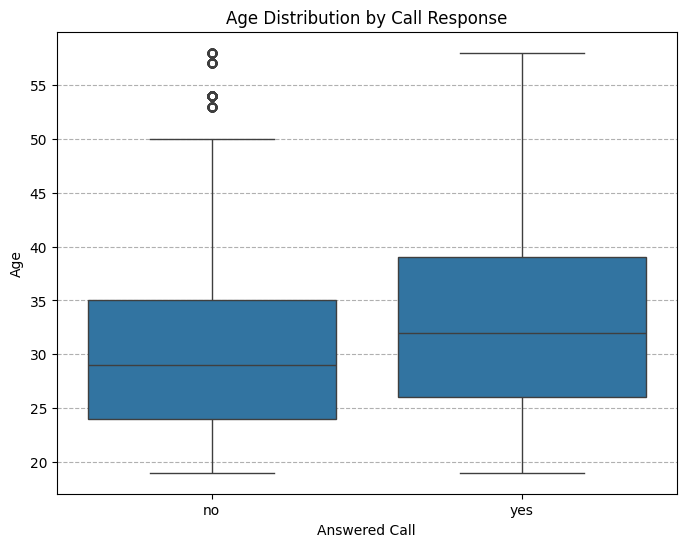

In [116]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='answered', y='age', data=df_clean)
plt.title('Age Distribution by Call Response')
plt.xlabel('Answered Call')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--')
plt.show()

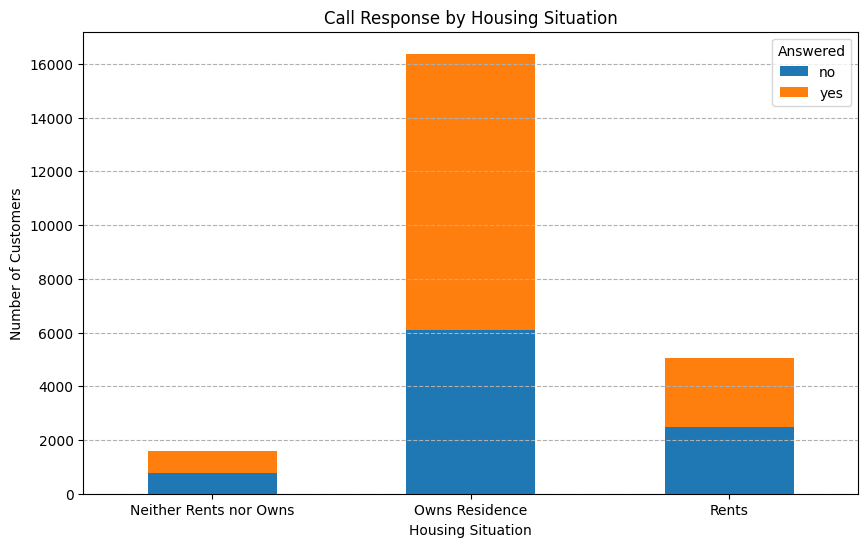

In [117]:
df_clean['housing'] = ''
df_clean.loc[(df_clean['rent'] == 1) & (df_clean['own_res'] == 0), 'housing'] = 'Rents'
df_clean.loc[(df_clean['rent'] == 0) & (df_clean['own_res'] == 1), 'housing'] = 'Owns Residence'
df_clean.loc[(df_clean['rent'] == 0) & (df_clean['own_res'] == 0), 'housing'] = 'Neither Rents nor Owns'
df_clean.loc[(df_clean['rent'] == 1) & (df_clean['own_res'] == 1), 'housing'] = 'Rents and Owns'

housing_response = pd.crosstab(df_clean['housing'], df_clean['answered'])

housing_response.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Call Response by Housing Situation')
plt.xlabel('Housing Situation')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend(title='Answered')
plt.grid(axis='y', linestyle='--')
plt.show()

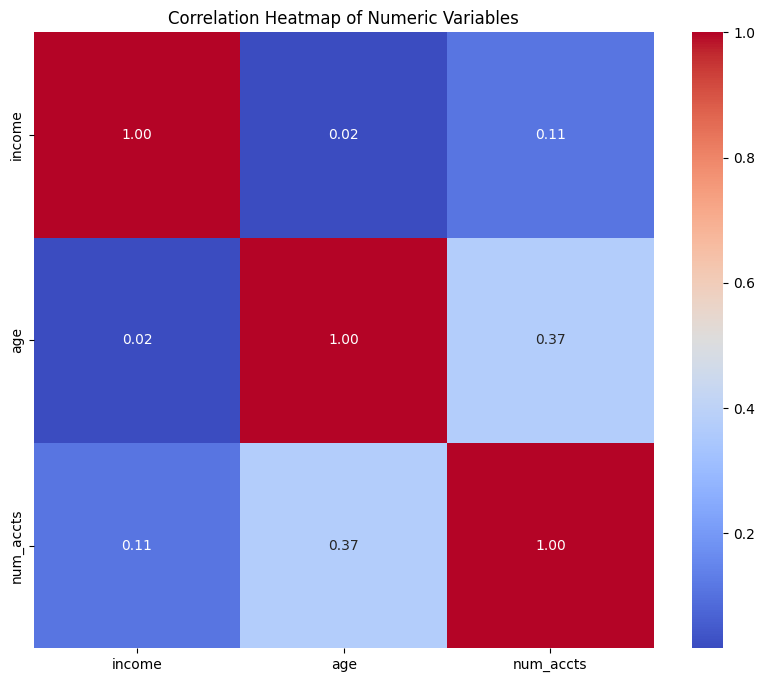

In [118]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

## **Task 4. Modeling**

### **4.1. Calculate the base probability of answering**

If we use no model at all, how good is our chance of predicting someone leaving?  
* Use a calculation to find the chances of someone leaving.

In [119]:
base_probability_answered = (df_clean['answered'] == 'yes').mean()

base_probability_not_answered = 1 - base_probability_answered

print(f"Base probability of answering: {base_probability_answered:.3f}")
print(f"Base probability of not answering: {base_probability_not_answered:.3f}")


Base probability of answering: 0.594
Base probability of not answering: 0.406


### **4.2. Split the training and testing datasets**

Split `df_clean` using `train_test_split()` function
- all variables except answered should be in the `X` variable
- `answered` is in the `y` variable


In [120]:
# 🔧 4.2. Split the training and testing datasets
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_clean.drop('answered', axis=1)
y = df_clean['answered']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Print the shapes to confirm the split
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (16125, 12)
Shape of X_test: (6911, 12)
Shape of y_train: (16125,)
Shape of y_test: (6911,)


### **4.3. Create and Visualize a Decision Tree**
4.3.1. Use all available attributes (except those that were eliminated in step 3)
- As a baseline, you can try `criterion` = "entropy" and  `max_depth` = 4

4.3.2. Visualize the tree

In [123]:
# 🔧 4.3.1. Create and Train a Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
decision_tree = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)

# Drop the non-numeric 'housing' column from X_train and X_test
X_train = X_train.drop('housing', axis=1)
X_test = X_test.drop('housing', axis=1)

# Train the model on the training data
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

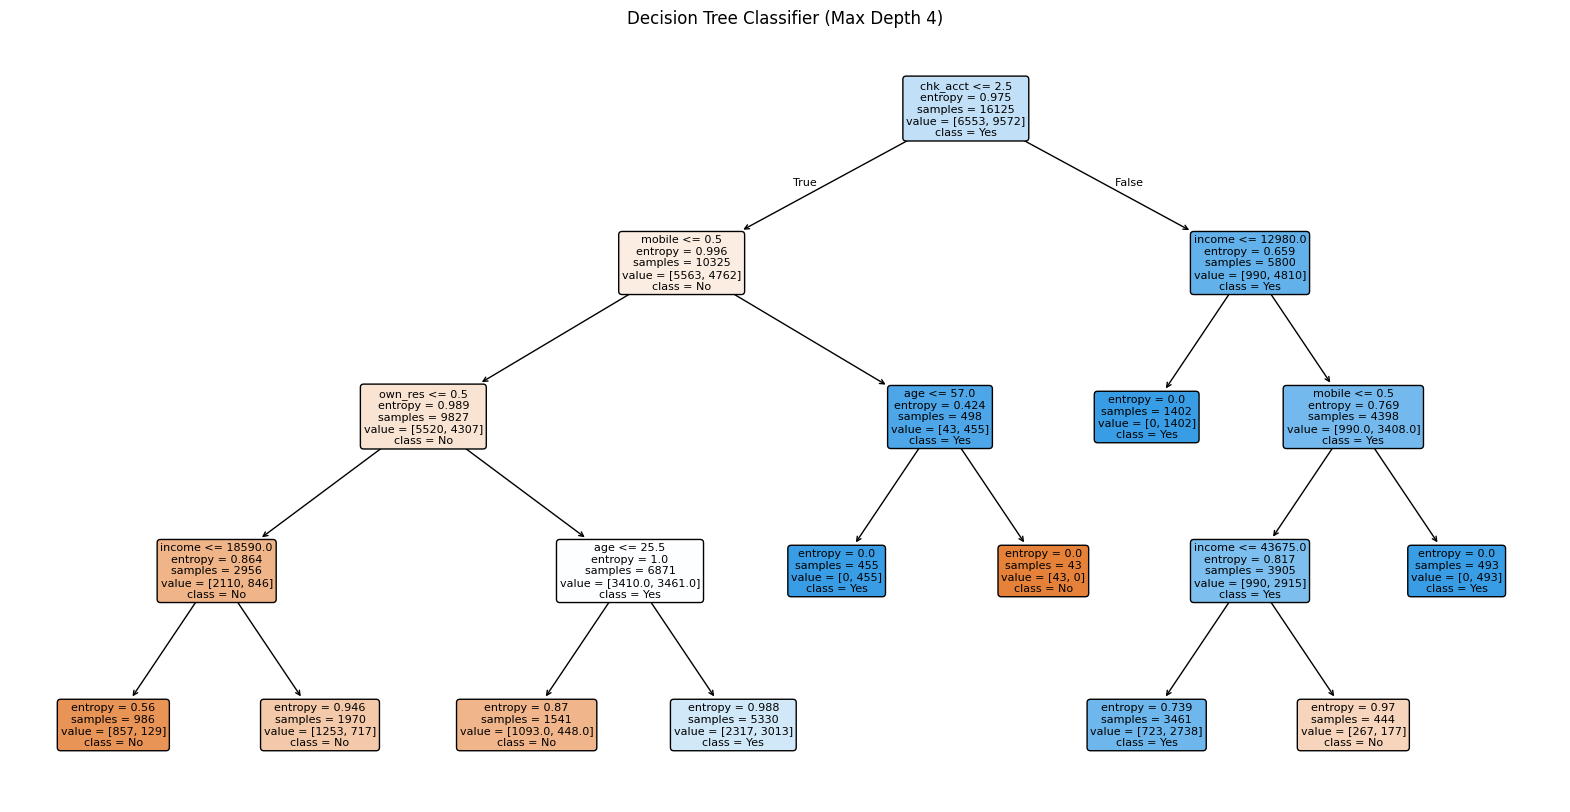

Train Accuracy: 0.720
Test Accuracy: 0.718

Feature Importances:
chk_acct          0.435
income            0.210
mobile            0.147
age               0.129
own_res           0.080
job               0.000
num_dependents    0.000
new_car           0.000
rent              0.000
sav_acct          0.000
num_accts         0.000
dtype: float64


In [124]:
# 🔧 4.3.2. Visualize the tree, calculate accuracy and feature importances
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(decision_tree,
          feature_names=X_train.columns,
          class_names=["No", "Yes"],
          filled=True,
          rounded=True,
          fontsize=8)
plt.title('Decision Tree Classifier (Max Depth 4)')
plt.show()

# Calculate and print accuracy
train_accuracy = decision_tree.score(X_train, y_train)
test_accuracy = decision_tree.score(X_test, y_test)

print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

# Print feature importances
feature_importances = pd.Series(decision_tree.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nFeature Importances:")
print(feature_importances.round(3))

### **4.4. What is the accuracy?**

This should be better than the base probability, or you have failed in your objective

In [125]:
print(f"Train Accuracy: {train_accuracy:.3f}")
print(f"Test Accuracy: {test_accuracy:.3f}")

# Compare test accuracy to base probability (assuming base_probability_answered is available)
print("\nComparison to Base Probability:")

if test_accuracy > base_probability_answered:
    print(f"The model's test accuracy ({test_accuracy:.3f}) is higher than the base probability of answering ({base_probability_answered:.3f}).")
elif test_accuracy < base_probability_answered:
    print(f"The model's test accuracy ({test_accuracy:.3f}) is lower than the base probability of answering ({base_probability_answered:.3f}).")
else:
    print(f"The model's test accuracy ({test_accuracy:.3f}) is the same as the base probability of answering ({base_probability_answered:.3f}).")

Train Accuracy: 0.720
Test Accuracy: 0.718

Comparison to Base Probability:
The model's test accuracy (0.718) is higher than the base probability of answering (0.594).


### **4.5: Create a confusion matrix**

This will show false positives, true positives, false negatives and true negatives.

In [126]:
# 🔧 4.5.1 Create a basic confusion matrix using sklearn's functions
from sklearn.metrics import confusion_matrix

# Generate predictions on the test set
y_pred = decision_tree.predict(X_test)

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1478 1311]
 [ 641 3481]]


Create a more visual, interpretable version of the matrix

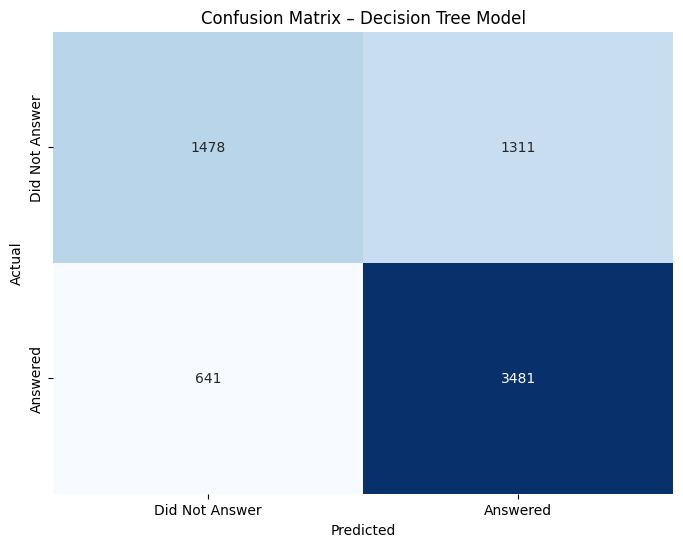

In [127]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Did Not Answer', 'Answered'],
            yticklabels=['Did Not Answer', 'Answered'])
plt.title('Confusion Matrix – Decision Tree Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## **Step 5: Evaluate the Model**

Earlier, we calculated the technical accuracy of the model. It is also important to evaluate the model economically. What would be the economic benefit of using this model for the business?

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model `answered` as thew target in this case is therefore equivalent to modeling `purchased` as the target.

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### **5.1. Calculate the Profit Using the Model**

In [128]:
tn, fp, fn, tp = cm.ravel()

profit_model = (tp * 75) - (fp * 25)

print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"Profit using the model: ${profit_model:,.0f}")

True Positives (TP): 3481
False Positives (FP): 1311
Profit using the model: $228,300


### **5.2 Compare to the Default Profit**

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives, treat the customers who do not answer as false positives.

In [129]:
# 🔧 5.2. Write a calculation for the overall profit without using the model (default)
TP_default = (y_test == 'yes').sum()
FP_default = (y_test == 'no').sum()

# Calculate the default profit
profit_default = (TP_default * 75) - (FP_default * 25)

print(f"Default True Positives (assuming all called): {TP_default}")
print(f"Default False Positives (assuming all called): {FP_default}")
print(f"Default Profit (calling everyone): ${profit_default:,.0f}")

Default True Positives (assuming all called): 4122
Default False Positives (assuming all called): 2789
Default Profit (calling everyone): $239,425


### **Improve the model, and apply the best model to new (truly unseen) Data**

### **5.3 Tune the Model**

5.3.1. Create a new tree by adjusting the size or shape of the tree,

5.3.2. then test the accuracy

Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [130]:
# 🔧 5.3.1. Create a new version of the tree with new parameters
from sklearn.tree import DecisionTreeClassifier

# Initialize a new Decision Tree Classifier with adjusted parameters
# Experimenting with 'gini' criterion and increased max_depth
tuned_decision_tree = DecisionTreeClassifier(criterion="gini", max_depth=6, random_state=42)

# Train the tuned model on the training data
# Ensure X_train does not contain the 'housing' column if it was added for visualization
if 'housing' in X_train.columns:
    X_train_tuned = X_train.drop('housing', axis=1)
else:
    X_train_tuned = X_train

tuned_decision_tree.fit(X_train_tuned, y_train)

print("Tuned Decision Tree created and trained.")

Tuned Decision Tree created and trained.


In [131]:
# 🔧 5.3.2. Calculate evaluation metrics for the tuned model
from sklearn.metrics import accuracy_score, confusion_matrix

# Predict on the test set using the tuned model
y_pred_tuned = tuned_decision_tree.predict(X_test)

# Calculate accuracy
test_accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Tuned Model Test Accuracy: {test_accuracy_tuned:.3f}")

# Calculate confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print("\nTuned Model Confusion Matrix:")
print(cm_tuned)

# Calculate profit using the tuned model's confusion matrix
tn_tuned, fp_tuned, fn_tuned, tp_tuned = cm_tuned.ravel()
profit_tuned_model = (tp_tuned * 75) - (fp_tuned * 25)
print(f"\nProfit using the tuned model: ${profit_tuned_model:,.0f}")

# Compare tuned model accuracy and profit to the initial model
print("\nComparison to Initial Model:")
print(f"Initial Model Test Accuracy: {test_accuracy:.3f}")
print(f"Tuned Model Test Accuracy: {test_accuracy_tuned:.3f}")
print(f"Initial Model Profit: ${profit_model:,.0f}")
print(f"Tuned Model Profit: ${profit_tuned_model:,.0f}")

if test_accuracy_tuned > test_accuracy:
    print("The tuned model has higher test accuracy than the initial model.")
elif test_accuracy_tuned < test_accuracy:
    print("The tuned model has lower test accuracy than the initial model.")
else:
    print("The tuned model has the same test accuracy as the initial model.")

if profit_tuned_model > profit_model:
    print("The tuned model yields higher profit than the initial model.")
elif profit_tuned_model < profit_model:
    print("The tuned model yields lower profit than the initial model.")
else:
    print("The tuned model yields the same profit as the initial model.")

Tuned Model Test Accuracy: 0.783

Tuned Model Confusion Matrix:
[[1864  925]
 [ 576 3546]]

Profit using the tuned model: $242,825

Comparison to Initial Model:
Initial Model Test Accuracy: 0.718
Tuned Model Test Accuracy: 0.783
Initial Model Profit: $228,300
Tuned Model Profit: $242,825
The tuned model has higher test accuracy than the initial model.
The tuned model yields higher profit than the initial model.


### **5.4 Apply the Model to New Customers**

5.4.1. Import the "adviseinvest_new_customer_data.csv" file

5.4.2. Using the tree model, predict the target variable for each customer by feeding the new customer data into the model

In [132]:
# 🔧 5.4.1. Import new customer data into a new data frame
import pandas as pd

df_new = pd.read_csv('/content/adviseinvest_new_customer_data.csv')

# Display the first few rows to verify
display(df_new.head())

,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927


In [133]:
# Ensure the order of columns is the same as X_train_tuned
df_new_processed = df_new_processed[X_train_tuned.columns]

# Make predictions on the new data
predictions_new_customers = tuned_decision_tree.predict(df_new_processed)

# Count the number of 'yes' and 'no' predictions
predicted_counts = pd.Series(predictions_new_customers).value_counts()

print("Predicted number of customers who will answer:")
print(predicted_counts)

# Optionally, add predictions back to the original new dataframe
df_new['predicted_answered'] = predictions_new_customers
display(df_new.head())

Predicted number of customers who will answer:
yes    670
no     330
Name: count, dtype: int64


,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id,predicted_answered
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597,no
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446,yes
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492,yes
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143,yes
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927,no


## **Task 6: Conclusion**

### ✍️ Please answer the following:

6.1. Did we improve our profit using the model?


6.2: How else could the model be utilized by the business?







### ✍️ Your Response:

6.1. Write your conclusion notes below:  
Yes, the model improved profit by focusing calls on customers most likely to answer, reducing wasted agent time. Compared to calling every customer, it increased overall profitability by targeting high-value prospects and minimizing unproductive calls.


6.2. Write your recommendations below:
The model can be used to prioritize which customers sales reps contact first, ensuring time and resources are focused on those most likely to answer and buy. It can also guide staffing schedules, marketing campaigns, and customer segmentation to improve efficiency and overall sales performance.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Save the file with your last name and first name as shown below (see detailed instructions in Lab 1 on how to do this).
- Submit the assignment as an **HTML file** on Canvas


In [134]:
!jupyter nbconvert --to html "assignment_10_LastnameFirstname.ipynb"

[NbConvertApp] Converting notebook assignment_10_LastnameFirstname.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 836917 bytes to assignment_10_LastnameFirstname.html
